In [1]:
import pandas as pd

In [2]:
tracks = pd.read_parquet("phase3_feature_engineering/feature engineered datasets/tracks_final.parquet")

In [4]:
genre_columns = [
    "Instrumental / Ambient Sounds", "Soft Acoustic / Classical", "Orchestral / Soundtrack",
    "Mid-tempo Pop / Indie", "Upbeat Electronic / Dance", "Slow & Melancholic (Sad Songs)",
    "Experimental / Jazz Fusion", "Lo-Fi / Chill Vibes"
]

sentiment_columns = ["joy", "calm", "sadness", "fear", "energizing", "dreamy"]

era_columns = ["Early Years", "Classic Era", "Golden Era", "2000s", "Modern Era"]

length_columns = ["Short", "Medium", "Long"]

meta_columns = ['track_popularity']

In [ ]:
249640

122058

In [33]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Define the feature columns
columns_for_similarity = genre_columns + sentiment_columns + era_columns + length_columns + meta_columns

# Select specific track_idx values
track_idx_1 = 2496  # Example track_idx 1
track_idx_2 = 10021 # Example track_idx 2

# Extract the rows corresponding to the track indices
row_1 = tracks.loc[tracks['track_idx'] == track_idx_1, columns_for_similarity]
row_2 = tracks.loc[tracks['track_idx'] == track_idx_2, columns_for_similarity]

# Check if both rows exist
if not row_1.empty and not row_2.empty:
    # Initialize the StandardScaler
    scaler = StandardScaler()
    
    # Fit and transform the scaler on the data from both tracks
    scaled_row_1 = scaler.fit_transform(row_1[columns_for_similarity])
    scaled_row_2 = scaler.transform(row_2[columns_for_similarity])  # Use transform (not fit_transform) to use the same scaling
    
    # Compute cosine similarity between the scaled rows
    similarity_score = cosine_similarity(scaled_row_1, scaled_row_2)[0, 0]
    
    print(f"Cosine Similarity between track_idx {track_idx_1} and {track_idx_2}: {similarity_score:.4f}")
else:
    print("One or both track_idx values not found in the playlist.")


Cosine Similarity between track_idx 2496 and 10021: 0.0000


In [45]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Define the feature columns
columns_for_similarity = genre_columns + sentiment_columns

# Select specific track_idx values
track_idx_1 = 249640  # Example track_idx 1
track_idx_2 = 122058  # Example track_idx 2

# Extract the rows corresponding to the track indices
row_1 = tracks.loc[tracks['track_idx'] == track_idx_1, columns_for_similarity]
row_2 = tracks.loc[tracks['track_idx'] == track_idx_2, columns_for_similarity]

# Check if both rows exist
if not row_1.empty and not row_2.empty:
    # Convert True/False values to 1/0 in the one-hot encoded columns
    # row_1[era_columns + length_columns] = row_1[era_columns + length_columns].astype(int)
    # row_2[era_columns + length_columns] = row_2[era_columns + length_columns].astype(int)
    
    # Handle any potential NaN values in other columns (for example, meta columns)
    row_1 = row_1.fillna(0)
    row_2 = row_2.fillna(0)
    
    # Initialize the StandardScaler
    scaler = StandardScaler()
    
    # Fit and transform the scaler on the data from both tracks
    scaled_row_1 = scaler.fit_transform(row_1[columns_for_similarity])
    scaled_row_2 = scaler.transform(row_2[columns_for_similarity])  # Use transform (not fit_transform) to use the same scaling
    
    # Compute cosine similarity between the scaled rows
    #similarity_score = cosine_similarity(scaled_row_1, scaled_row_2)[0, 0]
    similarity_score = cosine_similarity(row_1, row_2)[0, 0]

    
    print(f"Cosine Similarity between track_idx {track_idx_1} and {track_idx_2}: {similarity_score:.4f}")
else:
    print("One or both track_idx values not found in the playlist.")

Cosine Similarity between track_idx 249640 and 122058: 0.2689


In [35]:
print("Track 1 Data:")
print(row_1[columns_for_similarity])
print("Track 2 Data:")
print(row_2[columns_for_similarity])

print("Scaled Track 1 Data:")
print(scaled_row_1)
print("Scaled Track 2 Data:")
print(scaled_row_2)

print("Variance of Features in Track 1:")
print(row_1[columns_for_similarity].var())
print("Variance of Features in Track 2:")
print(row_2[columns_for_similarity].var())


Track 1 Data:
      Instrumental / Ambient Sounds  Soft Acoustic / Classical  \
2496                       0.005163                   0.050772   

      Orchestral / Soundtrack  Mid-tempo Pop / Indie  \
2496                 0.159606               0.762168   

      Upbeat Electronic / Dance  Slow & Melancholic (Sad Songs)  \
2496                   0.016046                        0.004632   

      Experimental / Jazz Fusion  Lo-Fi / Chill Vibes       joy      calm  \
2496                    0.001115             0.000498  0.022551  0.050957   

      ...    dreamy  Early Years  Classic Era  Golden Era  2000s  Modern Era  \
2496  ...  0.200566        False        False       False  False        True   

      Short  Medium  Long  track_popularity  
2496  False   False  True                38  

[1 rows x 23 columns]
Track 2 Data:
       Instrumental / Ambient Sounds  Soft Acoustic / Classical  \
10021                       0.004821                   0.729066   

       Orchestral / Sound

In [34]:
similarity_score_no_scaling = cosine_similarity(row_1[columns_for_similarity], row_2[columns_for_similarity])[0, 0]
print(f"Cosine Similarity without Scaling: {similarity_score_no_scaling:.4f}")

Cosine Similarity without Scaling: 0.9982


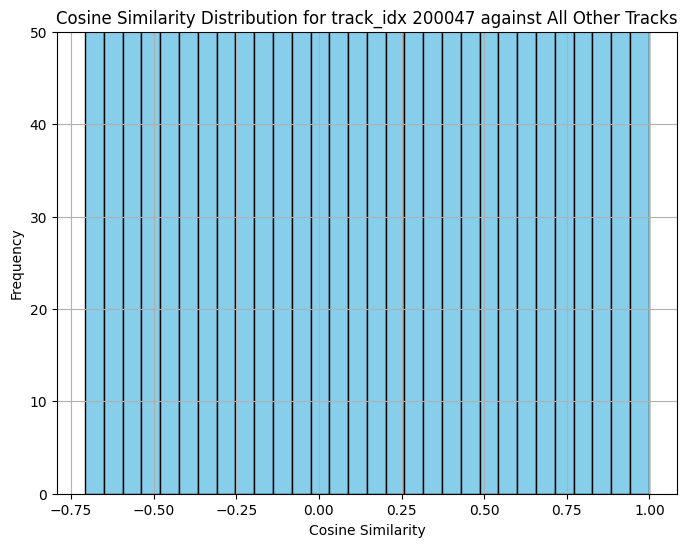

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Define the feature columns
columns_for_similarity = genre_columns + sentiment_columns + era_columns + length_columns + meta_columns

# Select the row for track_idx_1
track_idx_1 = 200047  # Example track_idx 1

# Extract the row corresponding to track_idx_1
row_1 = tracks.loc[tracks['track_idx'] == track_idx_1, columns_for_similarity]

# Check if the row exists
if not row_1.empty:
    # Compute cosine similarity between track_idx_1 and all other tracks
    other_tracks = tracks[tracks['track_idx'] != track_idx_1]
    
    # Extract the relevant columns for all other tracks
    other_tracks_data = other_tracks[columns_for_similarity]
    
    # Normalize the feature columns using StandardScaler
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(other_tracks_data)
    
    # Rescale row_1 to match the scaled features
    row_1_scaled = scaler.transform(row_1[columns_for_similarity])
    
    # Compute cosine similarities after scaling
    similarities = cosine_similarity(row_1_scaled, scaled_data)[0]
    
    # Plot the distribution of similarities
    plt.figure(figsize=(8, 6))
    plt.hist(similarities, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Cosine Similarity Distribution for track_idx {track_idx_1} against All Other Tracks")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.grid(True)

    # If the similarities are too close to 1, truncate the high values for better visualization
    plt.ylim(0, 50)  # Adjust the y-axis to zoom into the frequency part
    
    plt.show()
else:
    print(f"Track with track_idx {track_idx_1} not found in the playlist.")

In [17]:
playlist = pd.read_parquet("phase3_feature_engineering/feature engineered datasets/playlist_final.parquet")
cluster = pd.read_csv("segmented_playlists.csv")
cluster = cluster[['playlist_idx', 'cluster']] 
tracks = pd.read_parquet("phase3_feature_engineering/feature engineered datasets/tracks_final.parquet")

In [18]:
playlist = pd.merge(cluster, playlist, on='playlist_idx', how='left')

In [ ]:
import pandas as pd
import numpy as np


# Convert all indices to a standard Python int type
valid_track_ids = set(map(int, np.concatenate(playlist['track_idx_list']))) | \
                  set(map(int, np.concatenate(playlist['tracks_to_predict'])))

# Ensure track_idx column is also of type int
tracks['track_idx'] = tracks['track_idx'].astype(int)

# Filter tracks
filtered_tracks = tracks[tracks['track_idx'].isin(valid_track_ids)]

print(filtered_tracks)

        track_idx  album_idx  artist_idx  track_popularity  2000s  \
0               0      78824       20091                17  False   
1               1      19030       26382                18   True   
2               2      80563        1633                20  False   
3               3     118169       47069                41  False   
4               4      55985        4863                 5  False   
...           ...        ...         ...               ...    ...   
252231     252231     119490       51675                 4   True   
252232     252232      47583       50520                37  False   
252233     252233      41843       32287                19  False   
252234     252234      91014       45639                29  False   
252235     252235      14409       30292                18   True   

        Classic Era  Early Years  Golden Era  Modern Era   Long  ...  \
0             False        False       False        True   True  ...   
1             False        

In [22]:
filtered_tracks.to_csv("tracks_new.csv", index=False)

In [19]:
playlist = playlist.drop(columns=['artist_diversity', 'popularity_diversity', 'era_diversity', 'length_diversity', 'sentiment_diversity', 'genre_diversity'])

In [23]:
playlist.to_csv("playlist_with_segment.csv", index=False)